In [9]:
import os
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from PIL import Image

BASE_DIR = os.path.abspath("..")
DATA_DIR = os.path.join(BASE_DIR, "data", "processed")

TEST_DIR = os.path.join(DATA_DIR, "test")

IMAGE_SIZE = 224

test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])


In [10]:
test_dataset = datasets.ImageFolder(TEST_DIR, transform=test_transforms)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

num_classes = len(test_dataset.classes)
print("Test images:", len(test_dataset))
print("Classes:", num_classes)


Test images: 5448
Classes: 38


In [12]:
MODEL_PATH = os.path.join(BASE_DIR, "models", "leafgreen_resnet50.pth")

model = models.resnet50(weights=None)  # No weights because you’re loading trained ones
model.fc = nn.Linear(model.fc.in_features, num_classes)

model.load_state_dict(torch.load(MODEL_PATH, map_location="cpu"))
model.eval()


/tmp/ipykernel_64996/2220401003.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_PATH, map_location="cpu"))


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [13]:
correct = 0
total = 0

all_labels = []
all_preds = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_labels.extend(labels.numpy())
        all_preds.extend(preds.numpy())

accuracy = correct / total
accuracy


0.9939427312775331

In [14]:
print(classification_report(all_labels, all_preds, target_names=test_dataset.classes))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.98      1.00      0.99        63
                                 Apple___Black_rot       1.00      1.00      1.00        63
                          Apple___Cedar_apple_rust       1.00      1.00      1.00        28
                                   Apple___healthy       1.00      1.00      1.00       165
                               Blueberry___healthy       0.99      1.00      1.00       151
          Cherry_(including_sour)___Powdery_mildew       1.00      0.99      1.00       106
                 Cherry_(including_sour)___healthy       1.00      1.00      1.00        86
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.92      0.94      0.93        52
                       Corn_(maize)___Common_rust_       1.00      0.99      1.00       120
               Corn_(maize)___Northern_Leaf_Blight       0.96      0.96      0.

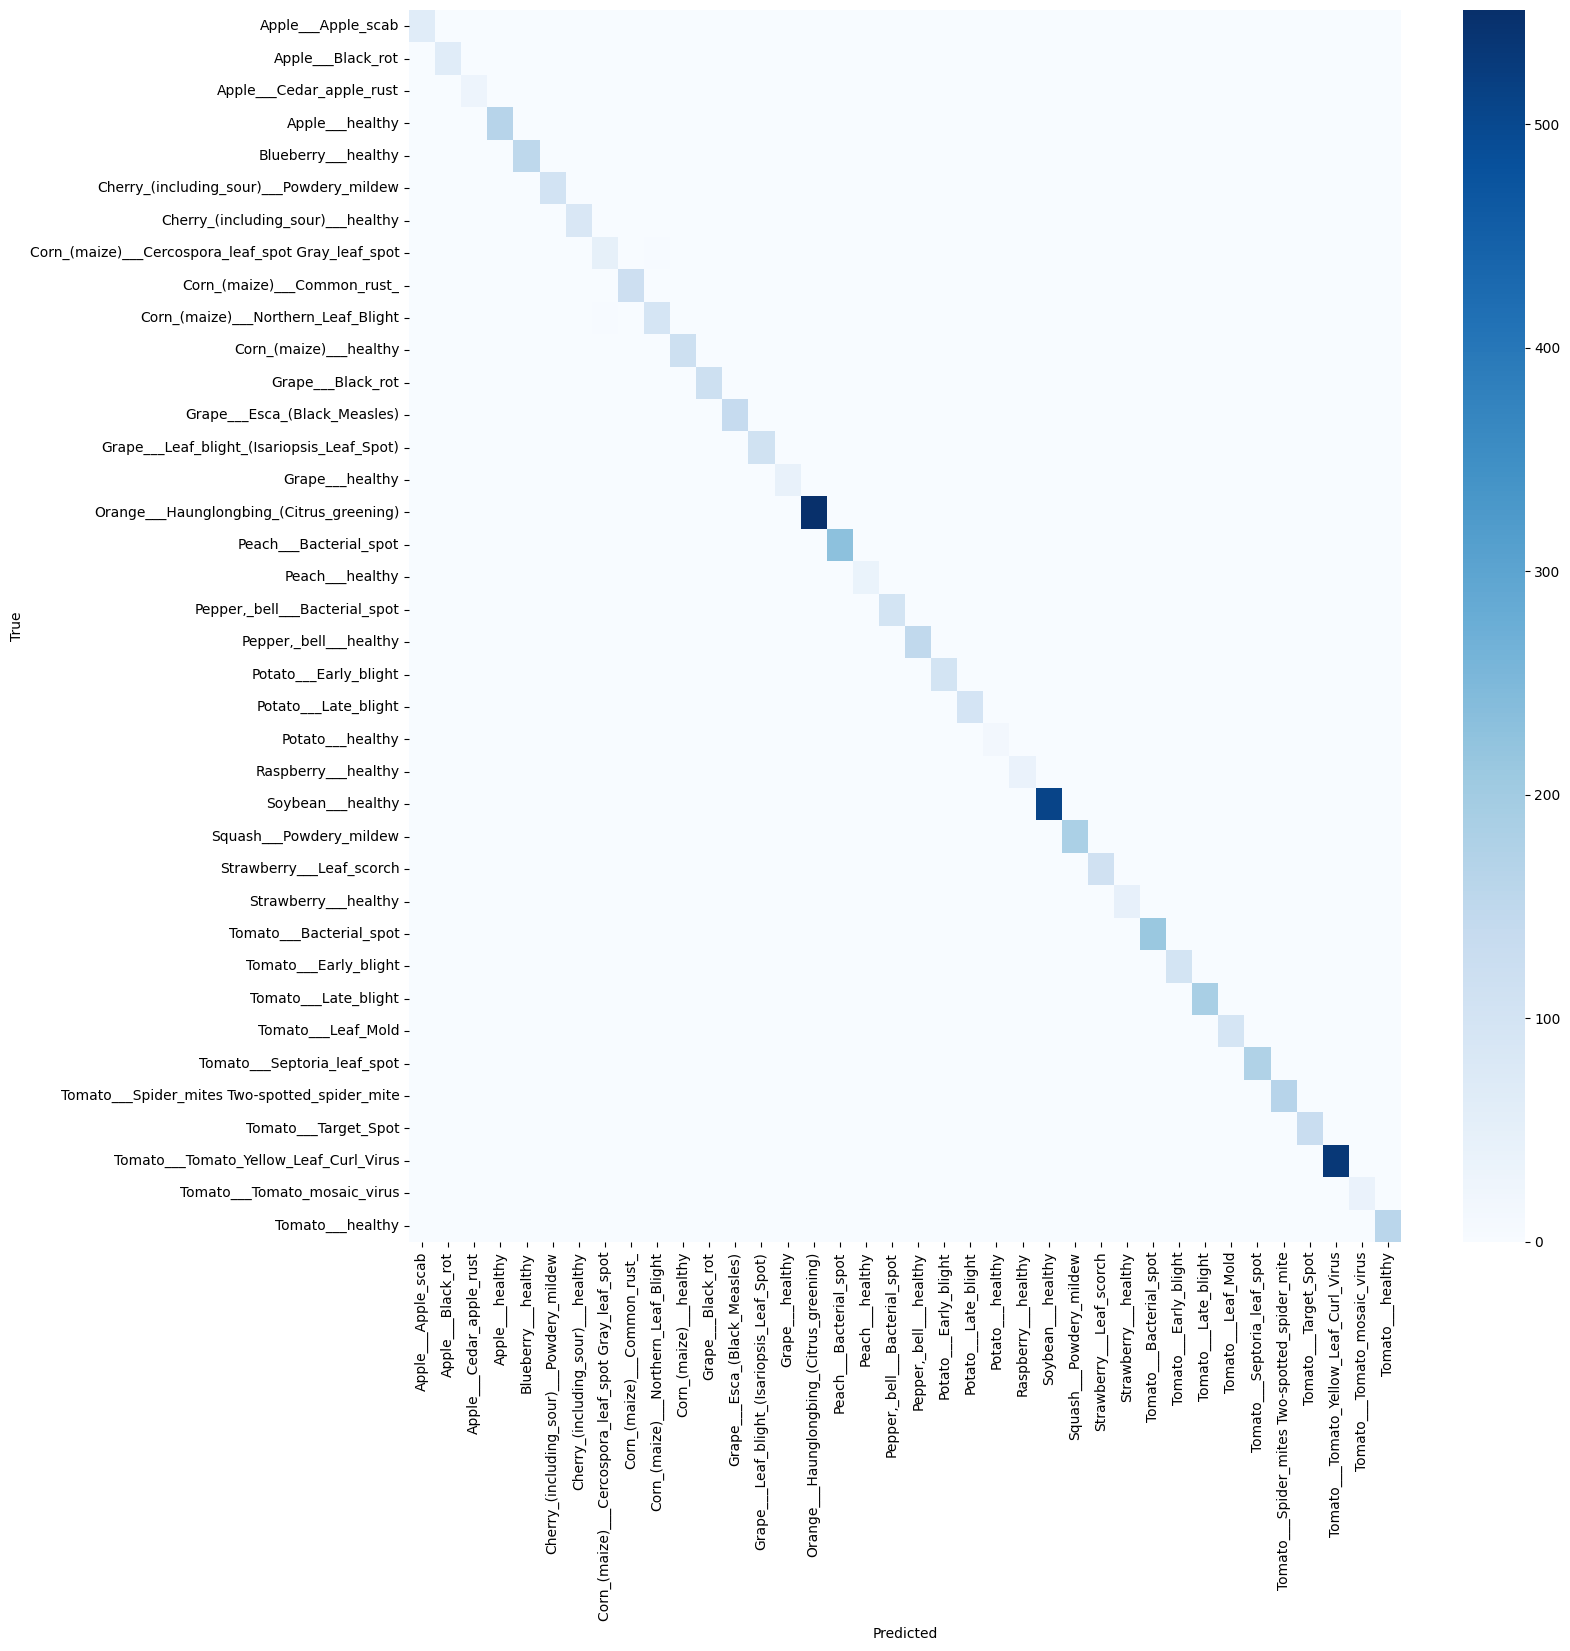

In [15]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(16, 16))
sns.heatmap(cm, xticklabels=test_dataset.classes, yticklabels=test_dataset.classes,
            annot=False, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

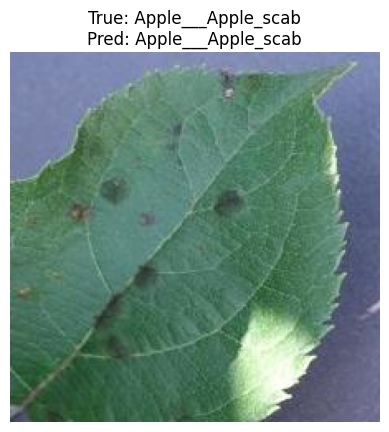

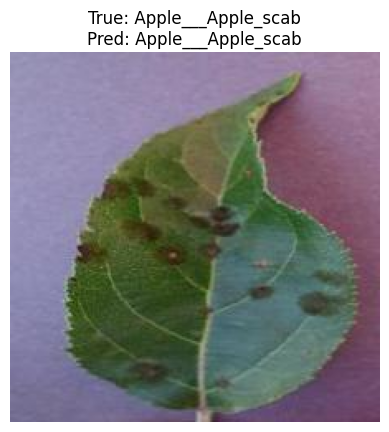

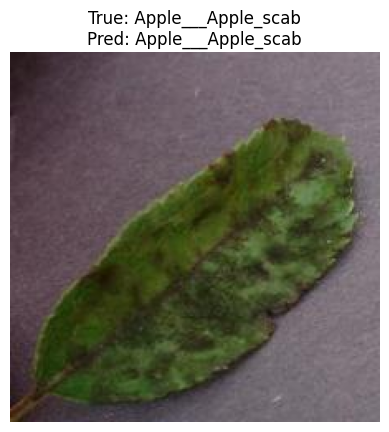

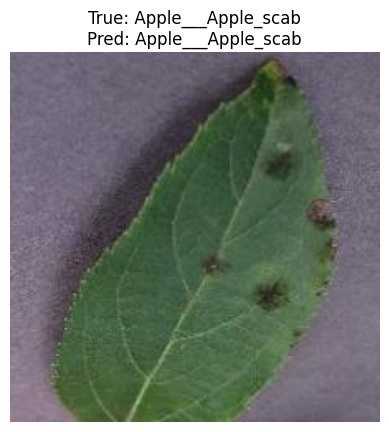

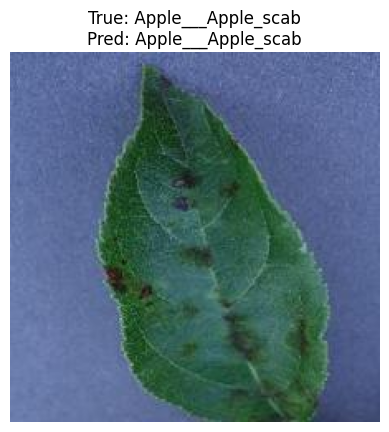

In [16]:
def show_image(img, label, pred):
    img = img.permute(1, 2, 0).numpy()
    plt.imshow(img)
    title = f"True: {test_dataset.classes[label]}\nPred: {test_dataset.classes[pred]}"
    plt.title(title)
    plt.axis("off")
    plt.show()

for i in range(5):
    img, label = test_dataset[i]
    output = model(img.unsqueeze(0))
    _, pred = torch.max(output, 1)
    show_image(img, label, pred.item())

In [17]:
# sample check for duplicate filenames across splits
import os, hashlib
def file_hash(path): 
    with open(path,'rb') as f: return hashlib.md5(f.read()).hexdigest()

base = "/path/to/processed"   # your local processed path
hashes = {}
for split in ["train","val","test"]:
    for root,_,files in os.walk(os.path.join(base,split)):
        for f in files:
            h = file_hash(os.path.join(root,f))
            if h in hashes:
                print("Duplicate across splits:", hashes[h], os.path.join(root,f))
            else:
                hashes[h] = os.path.join(root,f)
print("Duplicate check done")


Duplicate check done
